Write Python code for reading and visualizing the time series data contained in the
files A1_Training, A1_Validation.txt, and A1_Test.txt

In [ ]:
import csv
import numpy as np 

training = []
validation = []
testing = []


with open('A1_Training.txt') as training_file:
    plotting = csv.reader(training_file, delimiter='\t')

    for row in plotting:
        training.append(float(row[0]))

with open('A1_Validation.txt') as validation_file:
    plotting = csv.reader(validation_file, delimiter='\t')

    for row in plotting:
        validation.append(float(row[0]))

with open('A1_Test.txt') as test_file:
    plotting = csv.reader(test_file, delimiter='\t')

    for row in plotting:
        testing.append(float(row[0]))


training = np.array(training)
validation = np.array(validation)
testing = np.array(testing)


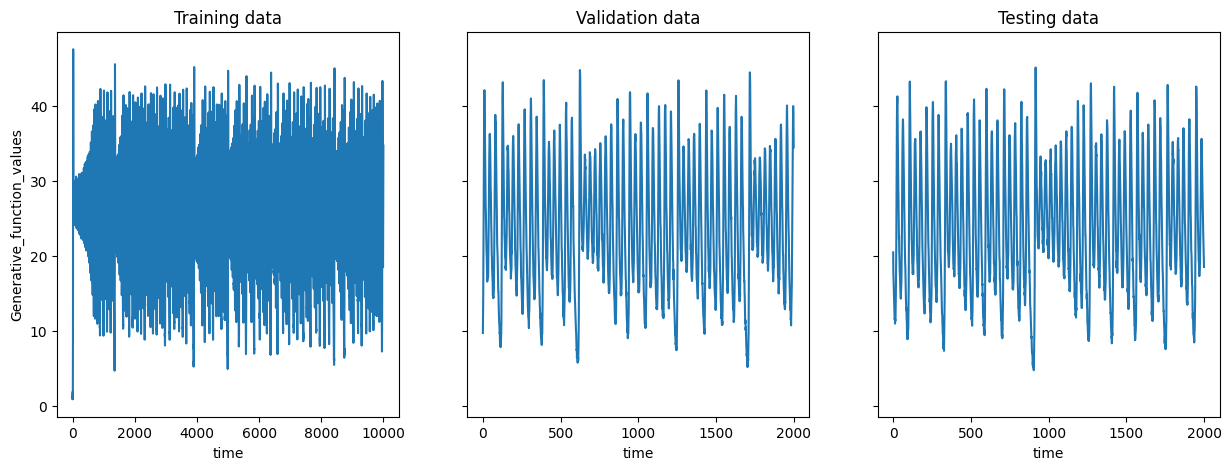

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axs[0].plot(training)

axs[0].set_ylabel('Generative_function_values')
axs[0].set_xlabel('time')
axs[0].set_title("Training data")


axs[1].plot(validation)
#axs[1].set_ylabel('Generative_function_values')
axs[1].set_xlabel('time')
axs[1].set_title("Validation data")

axs[2].plot(testing)
#axs[2].set_ylabel('Generative_function_values')
axs[2].set_xlabel('time')
axs[2].set_title("Testing data")

plt.show()

Fit ARMA model to training data. 
Use Nelder-Mead approach (in scipy.iptimize, set method to Nelder-Mead)
Output: plot showing the test data series and fit that was obtained from ARMA model over that set.
RMSE should be printed (as text)

One method (arma_inference) for making predictions and
one for computing loss function (arma_loss)
use res = minimize(arma_loss, np.zeros(p+q), method='Nelder-Mead', tol=1e-4)

In [37]:
from scipy.optimize import minimize

def arma_loss(params, p, q, training):

    phi = params[2:p+2]
    theta = params[p+2:p+q+2]
    c = params[0]
    sigma2 = params[1]
    
    predicted = np.zeros_like(training)
    error = np.zeros_like(training)

    for t in range(max(p,q), len(training)):
        next = c
        for i in range(len(phi)):
            next += phi[i] * training[t - i - 1]
        for j in range(len(theta)):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next
        error[t] = training[t] - predicted[t]
    
    n = len(training) - max(p, q)
    if sigma2 <= 0:
        return np.inf
    #var = np.mean(error[max(p, q):] ** 2)
    log_likelihood = - (n/2) * np.log(2 * np.pi) - (n/2) * np.log(sigma2) - (1/(2*sigma2)) * np.sum(error[max(p,q):]**2)
    return -log_likelihood


def arma_inference(training, p, q):

    initial_params = np.full(p+q+2, 0.1)
    res = minimize(arma_loss, initial_params, args = (p, q, training), method='Nelder-Mead', tol=1e-4)

    return(res)

p = 2
q = 2


res = arma_inference(training, p, q)
print(res)



#Should I select p and q to minimise the RMSE over the validation set?

C:\Users\Min Dator\AppData\Local\Temp\ipykernel_40684\2928995850.py:26: RuntimeWarning: overflow encountered in square
  log_likelihood = - (n/2) * np.log(2 * np.pi) - (n/2) * np.log(sigma2) - (1/(2*sigma2)) * np.sum(error[max(p,q):]**2)
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Min Dator\AppData\Local\Temp\ipykernel_40684\2928995850.py:18: RuntimeWarning: overflow encountered in scalar add
  next += theta[j] * error[t - j - 1]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 12388.060503181066
             x: [ 1.149e+00  7.285e-01  1.885e+00 -9.317e-01 -5.815e-01
                  3.297e-01]
           nit: 646
          nfev: 1008
 final_simplex: (array([[ 1.149e+00,  7.285e-01, ..., -5.815e-01,
                         3.297e-01],
                       [ 1.149e+00,  7.286e-01, ..., -5.815e-01,
                         3.297e-01],
                       ...,
                       [ 1.149e+00,  7.285e-01, ..., -5.815e-01,
                         3.297e-01],
                       [ 1.149e+00,  7.286e-01, ..., -5.814e-01,
                         3.297e-01]], shape=(7, 6)), array([ 1.239e+04,  1.239e+04,  1.239e+04,  1.239e+04,
                        1.239e+04,  1.239e+04,  1.239e+04]))


Graph

RMSE: 0.9094541021318719


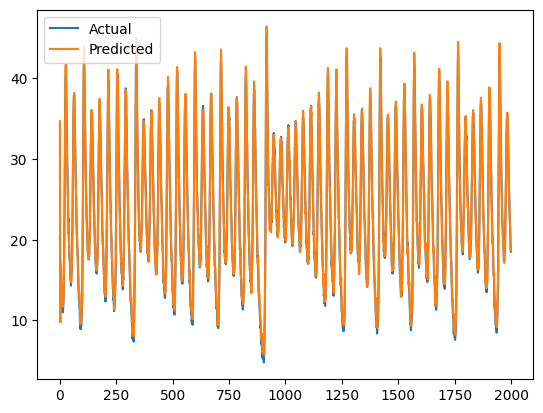

In [39]:
def arma_calculation(params, p, q, length, training, testing):

    phi = params[2:p+2]
    theta = params[p+2:p+q+2]
    c = params[0]
    sigma2 = params[1]
    
    predicted = np.zeros(length)
    #error = np.zeros_like(training)
    error = np.zeros(length)
    #predicted[:max(p, q)] = training[-max(p, q):]

    history = list(training[-max(p, q):])

    for t in range(length):
        next = c
        for i in range(p):
            next += phi[i] * history[- i - 1]
        for j in range(q):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next

        error[t] = testing[t] - predicted[t]

        history.append(testing[t])
    
    return predicted


results = arma_calculation(res.x, p, q, len(testing), training, testing)


rmse = np.sqrt(np.mean((testing - results) ** 2))
print("RMSE:", rmse)
plt.plot(testing, label='Actual')
plt.plot(results, label='Predicted')
plt.legend()
plt.show()

#Can you use the testing data to find predicted values?

Investigate Autocorrelation function (ACF) and the partial autocorrelation function (PACF) of series.
Use this to identify good pa dn 1 values
Include the ACF and PACF plots
Finally, select the p and q for whihc the RMSE over the validation set is minimal (after fitting the ARMA model over the trainign set)

<Figure size 640x480 with 0 Axes>

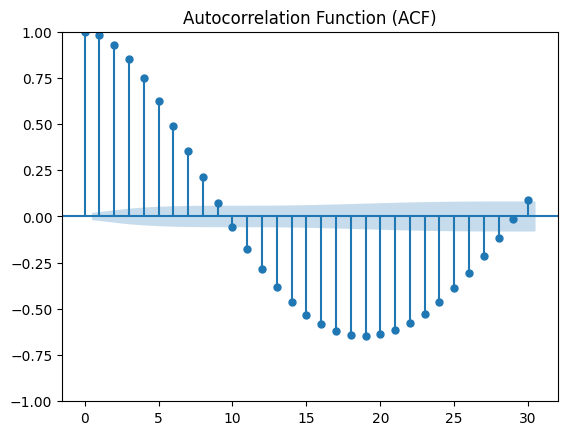

<Figure size 640x480 with 0 Axes>

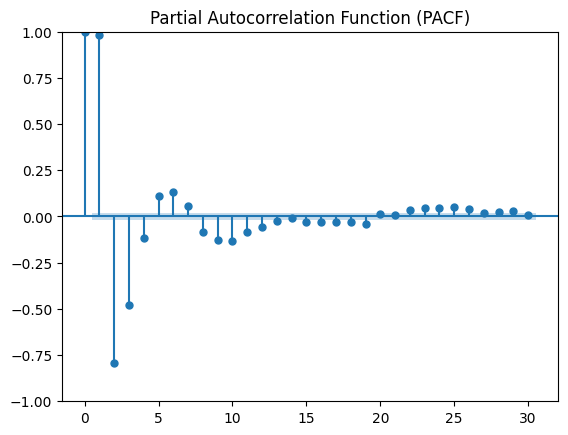

In [50]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

def plotting_ACF_and_PACF(data):
    data_array = np.array(data)

    data0 = data_array - np.mean(data_array)


    plt.figure()
    plot_acf(data0, lags=30)
    plt.title('Autocorrelation Function (ACF)')
    plt.show()

    plt.figure()
    plot_pacf(data0, lags=30)
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.show()

plotting_ACF_and_PACF(training) #Shoudl it be validation or training?


None of them cross the cutoff early, instead they slowly decrease.